In [ ]:
#setup

from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/Proyek_CRM_KELOMPOK')
sys.path.append(str(PROJECT_DIR))

from project_config import RAW_DATA_PATH, OUTPUT_DIR

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#load dataset

df_raw = pd.read_csv(RAW_DATA_PATH)

print('Jumlah baris dan kolom:', df_raw.shape)
df_raw.head()

Jumlah baris dan kolom: (388, 55)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,...,Less Delivery time,High Quality of package,Number of calls,Politeness,Freshness,Temperature,Good Taste,Good Quantity,Output,Reviews
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,...,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Yes,Nil\n
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,...,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Yes,Nil
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,...,Important,Very Important,Moderately Important,Very Important,Very Important,Important,Very Important,Moderately Important,Yes,"Many a times payment gateways are an issue, so..."
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,...,Very Important,Important,Moderately Important,Very Important,Very Important,Very Important,Very Important,Important,Yes,nil
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,...,Important,Important,Moderately Important,Important,Important,Important,Very Important,Very Important,Yes,NIL


In [5]:
# cek struktur data

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 55 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Age                                        388 non-null    int64  
 1   Gender                                     388 non-null    object 
 2   Marital Status                             388 non-null    object 
 3   Occupation                                 388 non-null    object 
 4   Monthly Income                             388 non-null    object 
 5   Educational Qualifications                 388 non-null    object 
 6   Family size                                388 non-null    int64  
 7   latitude                                   388 non-null    float64
 8   longitude                                  388 non-null    float64
 9   Pin code                                   388 non-null    int64  
 10  Medium (P1)               

In [7]:
#profil dataset

dataset_profile = pd.DataFrame({
    'metric': [
        'jumlah_baris',
        'jumlah_kolom',
        'jumlah_duplikat',
        'jumlah_kolom_numerik',
        'jumlah_kolom_kategorikal'
    ],
    'value': [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.duplicated().sum(),
        df_raw.select_dtypes(include=['int64', 'float64']).shape[1],
        df_raw.select_dtypes(include='object').shape[1]
    ]
})

dataset_profile

# simpan profile
dataset_profile_path = OUTPUT_DIR / 'dataset_profile.csv'
dataset_profile.to_csv(dataset_profile_path, index=False)

print('Output disimpan:', dataset_profile_path)

Output disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/dataset_profile.csv


In [8]:
#kamus kolom draf

column_dictionary = pd.DataFrame({
    'column_name': df_raw.columns,
    'data_type': df_raw.dtypes.astype(str).values,
    'missing_count': df_raw.isnull().sum().values,
    'unique_count': df_raw.nunique().values
})

column_dictionary

,column_name,data_type,missing_count,unique_count
0,Age,int64,0,16
1,Gender,object,0,2
2,Marital Status,object,0,3
3,Occupation,object,0,4
4,Monthly Income,object,0,5
5,Educational Qualifications,object,0,5
6,Family size,int64,0,6
7,latitude,float64,0,77
8,longitude,float64,0,76
9,Pin code,int64,0,77


In [9]:
#simpan kolom draft

column_dictionary_path = OUTPUT_DIR / 'column_dictionary_draft.csv'
column_dictionary.to_csv(column_dictionary_path, index=False)

print('Output disimpan:', column_dictionary_path)

Output disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/column_dictionary_draft.csv


In [10]:
#distribusi target mentah

target_distribution = (
    df_raw['Output']
    .value_counts()
    .reset_index()
)

target_distribution.columns = ['Output', 'jumlah']
target_distribution['persentase'] = target_distribution['jumlah'] / target_distribution['jumlah'].sum() * 100

target_distribution

,Output,jumlah,persentase
0,Yes,301,77.57732
1,No,87,22.42268


In [11]:
# simpan distribusi target

target_path = OUTPUT_DIR / 'target_distribution_raw.csv'
target_distribution.to_csv(target_path, index=False)

print('Output disimpan:', target_path)

Output disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/target_distribution_raw.csv


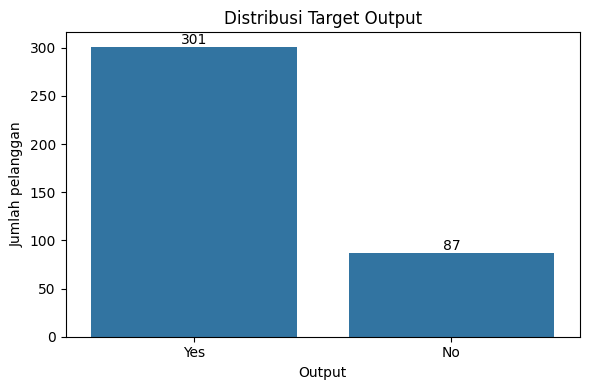

Grafik disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/01_target_distribution_raw.png


In [12]:
# Grafik distribusi target
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=target_distribution, x='Output', y='jumlah')

plt.title('Distribusi Target Output')
plt.xlabel('Output')
plt.ylabel('Jumlah pelanggan')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

chart_path = OUTPUT_DIR / '01_target_distribution_raw.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

print('Grafik disimpan:', chart_path)